## FUNKCJE POMOCNICZE

In [ ]:
from tqdm import tqdm
import kagglehub
from typing import List
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE


def download_data() -> pd.DataFrame:
    path = kagglehub.dataset_download("sadmansakib7/ecg-arrhythmia-classification-dataset")
    return pd.read_csv(f"{path}/INCART 2-lead Arrhythmia Database.csv")

def preproces_baseline_forest(df: pd.DataFrame):

    #drop unneccessary columns
    df = df.drop('record', axis = 1)
    df = df.dropna()
    df = df[df["type"] != 'Q']

    df["type"] = df["type"].map({'N': 0, 'VEB': 1, 'SVEB': 2, 'F': 3})

    #remove insignificant class

    X = df.drop('type', axis = 1)
    Y = df['type']

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

    ros = SMOTE()
    X_train_resampled, Y_train_resampled = ros.fit_resample(X_train, y_train)

    return X_train_resampled, X_test, Y_train_resampled, y_test

def preproces_without_oversampling(df: pd.DataFrame):
    #drop unneccessary columns
    df = df.drop('record', axis = 1)
    df = df.dropna()
    df = df[df["type"] != 'Q']

    df["type"] = df["type"].map({'N': 0, 'VEB': 1, 'SVEB': 2, 'F': 3})

    #remove insignificant class

    X = df.drop('type', axis = 1)
    Y = df['type']

    return train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

import numpy as np

def augment_minority_classes(X, y, multiplier=1):
    """
    X: (N, time_steps, 1)
    multiplier: Ile razy powielić mniejszość? 
                1 = Podwojenie (Oryginał + 1 kopia)
                2 = Potrojenie (Oryginał + 2 kopie)
    """
    time_steps = X.shape[1] 
    
    unique_classes, counts = np.unique(y, return_counts=True)
    max_count = np.max(counts)
    
    X_augmented = [X]
    y_augmented = [y]
    
    for cls in unique_classes:
        # Pomijamy klasę większościową
        # if counts[cls] == max_count:
        #     continue
            
        cls_indices = np.where(y == cls)[0]
        X_cls = X[cls_indices]
        
        n_needed = int(len(X_cls) * multiplier)
        
        print(f"Klasa {cls}: Oryginał {len(X_cls)} -> Generuję {n_needed} nowych próbek (Razem: {len(X_cls) + n_needed})")
        
        if n_needed <= 0: continue
            
        new_samples = []
        
        for _ in range(n_needed):
            idx = np.random.randint(len(X_cls))
            sample = X_cls[idx].copy()
                        
            # A. Skalowanie (Szansa 50%)
            if np.random.rand() < 0.5:
                scale = np.random.uniform(0.99, 1.01)
                sample = sample * scale

            # B. Szum (Szansa 50%)
            if np.random.rand() < 0.5:
                noise = np.random.normal(0, 0.01, sample.shape) 
                sample = sample + noise
            
            # C. Przesunięcie (Szansa 50%)
            if np.random.rand() < 0.5:
                shift = np.random.randint(-1, 2)
                if shift != 0:
                    if shift > 0:
                        sample = np.pad(sample, ((shift, 0), (0, 0)), mode='constant', constant_values=0)[:time_steps]
                    else:
                        sample = np.pad(sample, ((0, -shift), (0, 0)), mode='constant', constant_values=0)[-time_steps:]
            
            new_samples.append(sample)
            
        X_augmented.append(np.array(new_samples))
        y_augmented.append(np.full(n_needed, cls))
        
    return np.concatenate(X_augmented), np.concatenate(y_augmented)

def augment_to_target_counts(X, y, target_counts_dict):
    """
    Dostosowuje liczebność klas do wskazanych wartości.
    
    target_counts_dict: Słownik {label_klasy: docelowa_liczebnosc}
    Np. {0: 20000, 2: 15000, 3: 15000}
    
    - Jeśli target > current: augmentacja (szum, skalowanie, shift)
    - Jeśli target < current: losowy subsampling
    - Jeśli klasa nie jest w słowniku: pozostaje bez zmian
    """
    time_steps = X.shape[1] 
    
    X_final = []
    y_final = []
    
    unique_classes, counts = np.unique(y, return_counts=True)
    current_counts = dict(zip(unique_classes, counts))
    
    print(f"Stan początkowy: {current_counts}")
    
    for cls in unique_classes:
        cls_indices = np.where(y == cls)[0]
        X_cls = X[cls_indices]
        y_cls = y[cls_indices]
        
        if cls in target_counts_dict:
            target = target_counts_dict[cls]
            current = len(X_cls)
            
            if target < current:
                # SUBSAMPLING - losowy wybór próbek
                indices = np.random.choice(current, size=target, replace=False)
                X_final.append(X_cls[indices])
                y_final.append(y_cls[indices])
                print(f"Klasa {cls}: Subsampling z {current} do {target} (-{current - target} próbek)")
                
            elif target > current:
                # AUGMENTACJA - dodajemy oryginały + nowe próbki
                X_final.append(X_cls)
                y_final.append(y_cls)
                
                n_needed = target - current
                print(f"Klasa {cls}: Augmentacja z {current} do {target} (+{n_needed} próbek)")
                
                new_samples = []
                for _ in range(n_needed):
                    idx = np.random.randint(len(X_cls))
                    sample = X_cls[idx].copy()
                    
                    if np.random.rand() < 0.6:
                        scale = np.random.uniform(0.98, 1.02)
                        sample = sample * scale
                    if np.random.rand() < 0.4:
                        noise = np.random.normal(0, 0.005, sample.shape)
                        sample = sample + noise
                    if np.random.rand() < 0.6:
                        shift = np.random.randint(-2, 3)
                        if shift != 0:
                            if shift > 0:
                                sample = np.pad(sample, ((shift, 0), (0, 0)), mode='constant')[:time_steps]
                            else:
                                sample = np.pad(sample, ((0, -shift), (0, 0)), mode='constant')[-time_steps:]
                    
                    new_samples.append(sample)
                
                X_final.append(np.array(new_samples))
                y_final.append(np.full(n_needed, cls))
            else:
                # target == current
                print(f"Klasa {cls}: Już ma dokładnie {target} próbek. Bez zmian.")
                X_final.append(X_cls)
                y_final.append(y_cls)
        else:
            print(f"Klasa {cls}: Brak celu w słowniku. Pozostaje bez zmian ({len(X_cls)}).")
            X_final.append(X_cls)
            y_final.append(y_cls)

    return np.concatenate(X_final), np.concatenate(y_final)

## WIZUALIZACJE ZBIORU

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df = download_data()

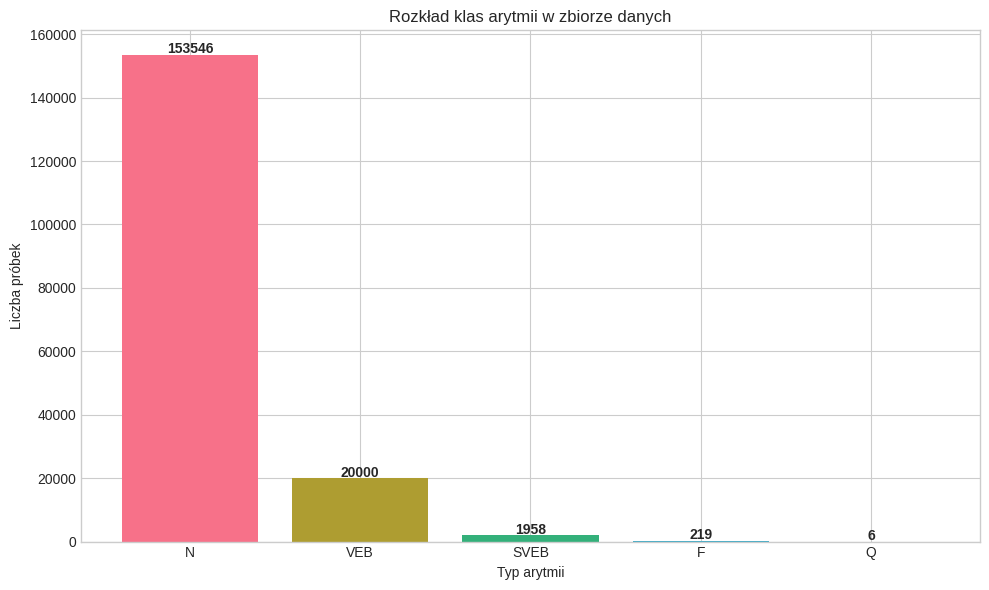

In [ ]:
# Rozkład klas arytmii
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = df['type'].value_counts()
ax.bar(class_counts.index, class_counts.values, color=sns.color_palette("husl", len(class_counts)))
ax.set_xlabel('Typ arytmii')
ax.set_ylabel('Liczba próbek')
ax.set_title('Rozkład klas arytmii w zbiorze danych')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

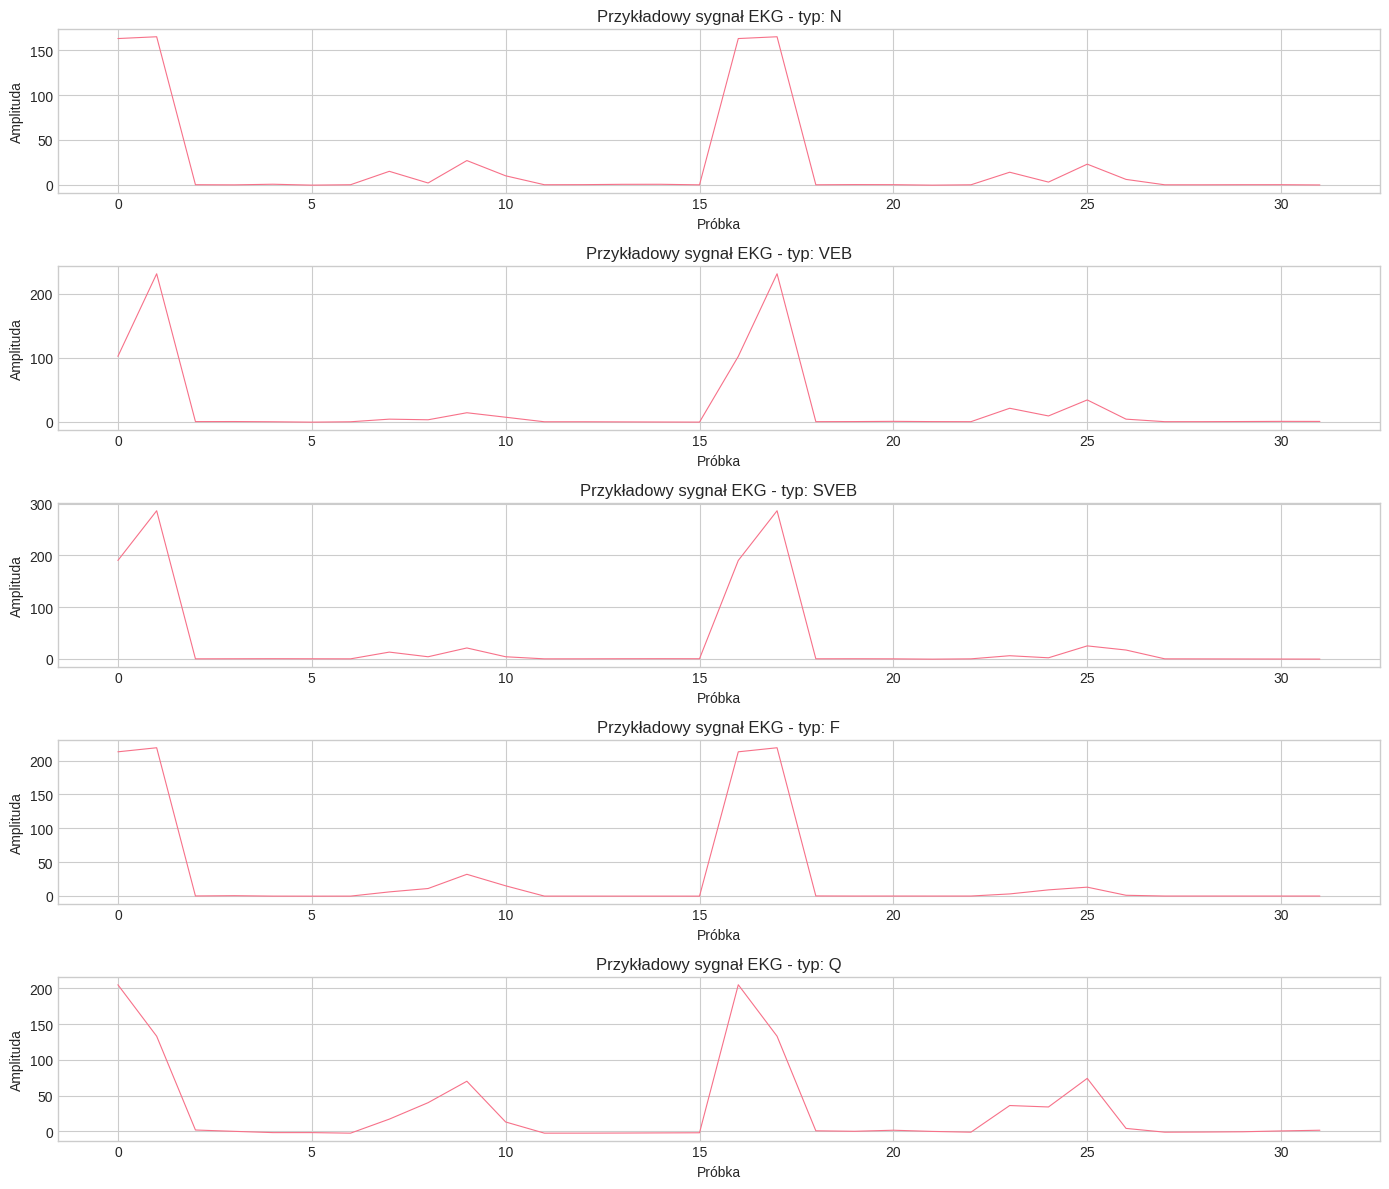

In [ ]:
# Przykładowe sygnały EKG dla różnych typów arytmii
signal_columns = [col for col in df.columns if col not in ['record', 'type']]

fig, axes = plt.subplots(5, 1, figsize=(14, 12))
types = df['type'].unique()

for idx, arrhythmia_type in enumerate(types):
    sample = df[df['type'] == arrhythmia_type].iloc[0]
    signal = sample[signal_columns].values
    axes[idx].plot(signal, linewidth=0.8)
    axes[idx].set_title(f'Przykładowy sygnał EKG - typ: {arrhythmia_type}')
    axes[idx].set_xlabel('Próbka')
    axes[idx].set_ylabel('Amplituda')

plt.tight_layout()
plt.show()

### Do modelowania usunięta zostanie klasa Q

## MODEL BAZOWY - RANDOM FOREST

In [ ]:
# Random Forest jako model bazowy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from scripts.prepare_data import download_data, preproces_baseline_forest
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


/home/kuba/RNN-ECG-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
df = download_data()
X_train, X_test, y_train, y_test = preproces_baseline_forest(df)

In [ ]:
forest = RandomForestClassifier()
forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = forest.predict(X_test)

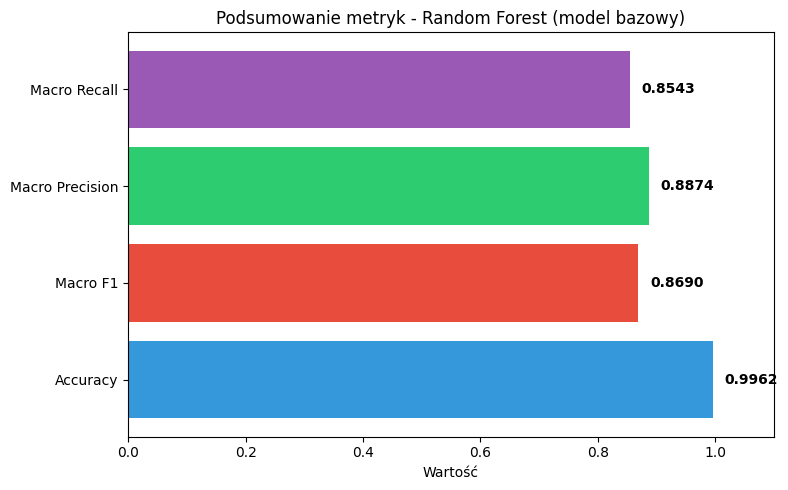


PODSUMOWANIE MODELU BAZOWEGO - RANDOM FOREST
Accuracy:        0.9962
Macro F1-score:  0.8690
Macro Precision: 0.8874
Macro Recall:    0.8543


In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average=None, zero_division=0)
rec = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average='macro')

# Podsumowanie metryk ogólnych
fig, ax = plt.subplots(figsize=(8, 5))

metrics_names = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_test, y_pred, average='macro')
metrics_values = [acc, f1, macro_precision, macro_recall]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']
bars = ax.barh(metrics_names, metrics_values, color=colors)

ax.set_xlim(0, 1.1)
ax.set_xlabel('Wartość')
ax.set_title('Podsumowanie metryk - Random Forest (model bazowy)')

for bar, value in zip(bars, metrics_values):
    ax.text(value + 0.02, bar.get_y() + bar.get_height()/2, 
            f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print("PODSUMOWANIE MODELU BAZOWEGO - RANDOM FOREST")
print(f"{'='*50}")
print(f"Accuracy:        {acc:.4f}")
print(f"Macro F1-score:  {f1:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")

2. CROSS-VALIDATION (5-fold) z SMOTE
Uwaga: To może potrwać kilka minut...

Accuracy per fold: [0.99550434 0.99604496 0.99604496 0.99692693 0.99615866]
Macro F1 per fold: [0.84117545 0.84648625 0.84368211 0.85611137 0.8623618 ]

Accuracy: 0.9961 (+/- 0.0009)
Macro F1: 0.8500 (+/- 0.0160)

Accuracy per fold: [0.99550434 0.99604496 0.99604496 0.99692693 0.99615866]
Macro F1 per fold: [0.84117545 0.84648625 0.84368211 0.85611137 0.8623618 ]

Accuracy: 0.9961 (+/- 0.0009)
Macro F1: 0.8500 (+/- 0.0160)


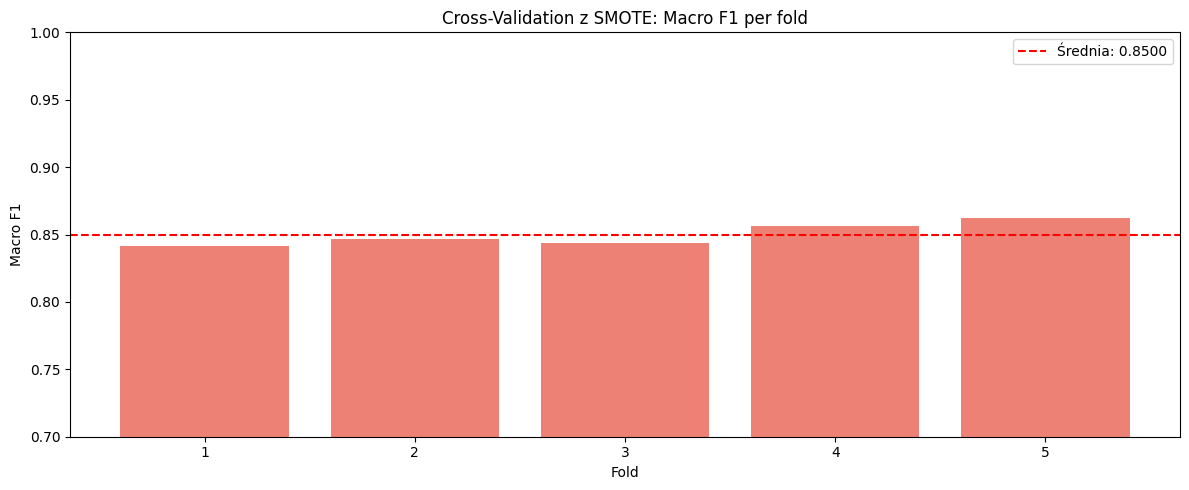

In [ ]:
#CROSS-VALIDATION 
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

print("="*60)
print("2. CROSS-VALIDATION (5-fold) z SMOTE")
print("="*60)
print("Uwaga: To może potrwać kilka minut...")

df_cv = df.copy()
df_cv = df_cv.drop('record', axis=1)
df_cv = df_cv.dropna()
df_cv = df_cv[df_cv["type"] != 'Q']
df_cv["type"] = df_cv["type"].map({'N': 0, 'VEB': 1, 'SVEB': 2, 'F': 3})

X_cv = df_cv.drop('type', axis=1)
y_cv = df_cv['type']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

cv_accuracy = cross_val_score(pipeline, X_cv, y_cv, cv=cv, scoring='accuracy')
cv_f1 = cross_val_score(pipeline, X_cv, y_cv, cv=cv, scoring='f1_macro')

print(f"\nAccuracy per fold: {cv_accuracy}")
print(f"Macro F1 per fold: {cv_f1}")
print(f"\nAccuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std()*2:.4f})")
print(f"Macro F1: {cv_f1.mean():.4f} (+/- {cv_f1.std()*2:.4f})")

fig, axes = plt.subplots(1, 1, figsize=(12, 5))

# F1 per fold
axes.bar(range(1, 6), cv_f1, color='#e74c3c', alpha=0.7)
axes.axhline(y=cv_f1.mean(), color='red', linestyle='--', label=f'Średnia: {cv_f1.mean():.4f}')
axes.set_xlabel('Fold')
axes.set_ylabel('Macro F1')
axes.set_title('Cross-Validation z SMOTE: Macro F1 per fold')
axes.legend()
axes.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

## MODELE DENSE

In [ ]:
import tensorflow as tf
from keras.utils import to_categorical
from keras import layers, models, optimizers, metrics, regularizers
import datetime

import sys
sys.path.append('..')
from scripts.prepare_data import download_data, preproces_without_oversampling, augment_to_target_counts

import numpy as np

2026-01-15 19:50:11.725185: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 19:50:11.755684: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 19:50:12.530942: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/kuba/RNN-ECG-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning

In [2]:
# Pobieranie i wstępne przetwarzanie danych
df_base_preproc = download_data()
X_train, X_test, y_train, y_test = preproces_without_oversampling(df_base_preproc)

In [3]:
X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train

X_train_flat = X_train_arr
X_test_flat = X_test_arr

print(f"X_train_flat shape (dla Dense): {X_train_flat.shape}")

# Augmentacja mniejszościowych klas
X_train_3d = X_train_flat.reshape((X_train_flat.shape[0], X_train_flat.shape[1], 1))
X_train_aug_3d, y_train_aug = augment_to_target_counts(X_train_3d, y_train_np, {2: 16000, 3: 16000})

X_train_aug = X_train_aug_3d.reshape((X_train_aug_3d.shape[0], -1))

print(f"\nPo augmentacji:")
print(f"X_train_aug shape: {X_train_aug.shape}")
print(f"Rozkład klas: {np.unique(y_train_aug, return_counts=True)}")

perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

X_train_flat shape (dla Dense): (140578, 32)
Stan początkowy: {np.int64(0): np.int64(122837), np.int64(1): np.int64(16000), np.int64(2): np.int64(1566), np.int64(3): np.int64(175)}
Klasa 0: Brak celu w słowniku. Pozostaje bez zmian (122837).
Klasa 1: Brak celu w słowniku. Pozostaje bez zmian (16000).
Klasa 2: Augmentacja z 1566 do 16000 (+14434 próbek)
Klasa 3: Augmentacja z 175 do 16000 (+15825 próbek)

Po augmentacji:
X_train_aug shape: (170837, 32)
Rozkład klas: (array([0, 1, 2, 3]), array([122837,  16000,  16000,  16000]))


In [4]:
# Tworzenie datasetów
batch_size = 32

y_train_preproc = to_categorical(y_train_aug)
y_test_preproc = to_categorical(y_test)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_aug, y_train_preproc)) \
    .shuffle(1000) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_flat, y_test_preproc)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

print(f"Train batches: {len(X_train_aug) // batch_size}")
print(f"Val batches: {len(X_test_flat) // batch_size}")

Train batches: 5338
Val batches: 1098


I0000 00:00:1768503019.997923  106464 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1218 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


In [5]:
dense_model = models.Sequential([
    layers.Input(shape=(X_train_aug.shape[1],)),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.L2()),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.L2()),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

dense_model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[metrics.F1Score(average='macro')]
)

log_dir = "../logs/fit/dense_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_score', patience=5, restore_best_weights=True, mode='max')

history = dense_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[tensorboard_callback, early_stopping]
)

dense_model.save("models/dense_baseline.keras")

Epoch 1/30


2026-01-15 19:50:23.028380: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fe320016420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-15 19:50:23.028391: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-01-15 19:50:23.045630: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-15 19:50:23.143077: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-15 19:50:23.212680: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:50:23.212742: I e

 129/5339 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - f1_score: 0.3672 - loss: 2.1901

I0000 00:00:1768503024.984330  106621 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5324/5339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - f1_score: 0.7294 - loss: 0.6654

2026-01-15 19:50:32.472753: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:50:32.890923: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_948', 24 bytes spill stores, 24 bytes spill loads

2026-01-15 19:50:32.954655: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_948', 20 bytes spill stores, 20 bytes spill loads



5339/5339 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.7296 - loss: 0.6648

2026-01-15 19:50:34.068110: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:50:34.381705: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 100 bytes spill stores, 100 bytes spill loads



5339/5339 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - f1_score: 0.7797 - loss: 0.4347 - val_f1_score: 0.6986 - val_loss: 0.1706
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - f1_score: 0.8230 - loss: 0.3106 - val_f1_score: 0.6845 - val_loss: 0.1710
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score: 0.8313 - loss: 0.2937 - val_f1_score: 0.6623 - val_loss: 0.1690
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - f1_score: 0.8369 - loss: 0.2856 - val_f1_score: 0.6731 - val_loss: 0.1580
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - f1_score: 0.8417 - loss: 0.2800 - val_f1_score: 0.6839 - val_loss: 0.1464
Epoch 6/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - f1_score: 0.8453 - loss: 0.2767 - val_f1_score: 0.6979 - val_loss: 0.1384


In [6]:
# Większy model Dense
dense_larger = models.Sequential([
    layers.Input(shape=(X_train_aug.shape[1],)),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.L2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.L2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

dense_larger.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.001),
    metrics=[metrics.F1Score(average='macro')]
)

log_dir = "../logs/fit/dense_larger_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_f1_score', patience=5, restore_best_weights=True, mode='max')

history = dense_larger.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[tensorboard_callback, early_stopping]
)

dense_larger.save("models/dense_larger.keras")

Epoch 1/30


2026-01-15 19:55:49.265594: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:55:49.265616: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:55:49.265646: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:55:50.050080: I external/l

5305/5339 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - f1_score: 0.7487 - loss: 0.4831

2026-01-15 19:55:58.462199: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:55:58.462218: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:55:58.840164: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1582', 28 bytes spill stores, 28 bytes spill loads



5339/5339 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - f1_score: 0.7491 - loss: 0.4822

2026-01-15 19:56:00.476218: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-15 19:56:00.632467: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 8 bytes spill stores, 8 bytes spill loads

2026-01-15 19:56:02.220085: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_81', 8 bytes spill stores, 8 bytes spill loads



5339/5339 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - f1_score: 0.8145 - loss: 0.3525 - val_f1_score: 0.6761 - val_loss: 0.1507
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score: 0.8669 - loss: 0.2506 - val_f1_score: 0.7358 - val_loss: 0.1204
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score: 0.8771 - loss: 0.2381 - val_f1_score: 0.7379 - val_loss: 0.1197
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score: 0.8794 - loss: 0.2344 - val_f1_score: 0.7168 - val_loss: 0.1302
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - f1_score: 0.8812 - loss: 0.2307 - val_f1_score: 0.7509 - val_loss: 0.1176
Epoch 6/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - f1_score: 0.8824 - loss: 0.2306 - val_f1_score: 0.7439 - val_loss: 0.1170
Epoch 7/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - f1_score: 0.8851 - loss: 0.2291 - val_f1_score: 0.6957 - val_loss: 0.1242
Epoch 8/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - f1_score: 0.8845 - loss: 0.2280 - val_f1_sc

## MODELE LSTM

In [1]:
import tensorflow as tf
from keras.utils import to_categorical
from keras import layers, models, optimizers, metrics
import datetime


import sys
sys.path.append('..')
from scripts.prepare_data import download_data, preproces_baseline_forest, preproces_without_oversampling, augment_minority_classes
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import numpy as np

2026-01-11 14:18:20.485305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 14:18:20.517098: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-11 14:18:21.330685: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 14:18:21.330685: I tensorflow/core/util/port.cc:153] oneDNN custom operations ar

In [ ]:
df_base_preproc = download_data()
X_train, X_test, y_train, y_test = preproces_without_oversampling(df_base_preproc)

In [4]:
time_steps = X_train.shape[1]
features = 1

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test

X_train_preproc = X_train_arr.reshape((X_train.shape[0], time_steps, features))
X_test_preproc = X_test_arr.reshape((X_test.shape[0], time_steps, features))

#augment
X_train_aug, y_train_aug = augment_minority_classes(X_train_preproc, y_train)
perm = np.random.permutation(len(X_train_aug))
X_train_preproc = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

batch_size = 32

y_train_preproc = to_categorical(y_train_aug)
y_test_preproc = to_categorical(y_test)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_preproc, y_train_preproc)) \
    .shuffle(1000) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_preproc, y_test_preproc)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

In [ ]:
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    layers.BatchNormalization(),
    layers.LSTM(32, recurrent_dropout=0.3, return_sequences=False),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.0003),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=10,
                       callbacks=[tensorboard_callback],
                       )

deep_rnn.save("models/lstm_with_dense.keras")

Epoch 1/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 354s 23ms/step - f1_score: 0.7025 - loss: 0.7275 - val_f1_score: 0.5872 - val_loss: 0.2415
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 354s 23ms/step - f1_score: 0.7025 - loss: 0.7275 - val_f1_score: 0.5872 - val_loss: 0.2415
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 351s 23ms/step - f1_score: 0.8266 - loss: 0.4907 - val_f1_score: 0.6117 - val_loss: 0.2124
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 351s 23ms/step - f1_score: 0.8266 - loss: 0.4907 - val_f1_score: 0.6117 - val_loss: 0.2124
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 349s 23ms/step - f1_score: 0.8446 - loss: 0.4492 - val_f1_score: 0.6134 - val_loss: 0.2118
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 349s 23ms/step - f1_score: 0.8446 - loss: 0.4492 - val_f1_score: 0.6134 - val_loss: 0.2118
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 348s 23ms/step - f1_score: 0.8532 - loss: 0.4254 - val_f1_score: 0.6188 - val_loss: 0.2151
Epoch 5/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 348s 23ms/s

In [ ]:
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(32, recurrent_dropout=0.3, return_sequences=True)),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(16, recurrent_dropout=0.3, return_sequences=False)),
    layers.Dense(128, activation="relu"),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.003),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=10,
                       callbacks=[tensorboard_callback],
                       )

deep_rnn.save("models/aug_double_lstm_bidirectional.keras")

Epoch 1/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1171s 76ms/step - f1_score: 0.9211 - loss: 0.2300 - val_f1_score: 0.7283 - val_loss: 0.0603
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1171s 76ms/step - f1_score: 0.9211 - loss: 0.2300 - val_f1_score: 0.7283 - val_loss: 0.0603
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1154s 75ms/step - f1_score: 0.9683 - loss: 0.0995 - val_f1_score: 0.7056 - val_loss: 0.0702
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1154s 75ms/step - f1_score: 0.9683 - loss: 0.0995 - val_f1_score: 0.7056 - val_loss: 0.0702
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1129s 74ms/step - f1_score: 0.9758 - loss: 0.0762 - val_f1_score: 0.7319 - val_loss: 0.0551
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1129s 74ms/step - f1_score: 0.9758 - loss: 0.0762 - val_f1_score: 0.7319 - val_loss: 0.0551
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1133s 74ms/step - f1_score: 0.9796 - loss: 0.0643 - val_f1_score: 0.7330 - val_loss: 0.0589
Epoch 5/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1133

In [ ]:
from keras import regularizers

deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(32, recurrent_dropout=0.3, return_sequences=True, kernel_regularizer=regularizers.L2())),
    layers.BatchNormalization(),
    layers.Bidirectional(layers.LSTM(16, recurrent_dropout=0.3, return_sequences=False, kernel_regularizer=regularizers.L2())),
    layers.Dense(128, activation="relu"),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.003),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", patience = 3, restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=10,
                       callbacks=[tensorboard_callback, early_stopping],
                       )

deep_rnn.save("models/aug_double_lstm_bidirectional_l2.keras")

Epoch 1/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1175s 76ms/step - f1_score: 0.8860 - loss: 0.3814 - val_f1_score: 0.6918 - val_loss: 0.1460
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1175s 76ms/step - f1_score: 0.8860 - loss: 0.3814 - val_f1_score: 0.6918 - val_loss: 0.1460
Epoch 2/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1159s 75ms/step - f1_score: 0.9399 - loss: 0.2249 - val_f1_score: 0.7115 - val_loss: 0.1277
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1159s 75ms/step - f1_score: 0.9399 - loss: 0.2249 - val_f1_score: 0.7115 - val_loss: 0.1277
Epoch 3/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1146s 75ms/step - f1_score: 0.9519 - loss: 0.1881 - val_f1_score: 0.4090 - val_loss: 0.4729
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1146s 75ms/step - f1_score: 0.9519 - loss: 0.1881 - val_f1_score: 0.4090 - val_loss: 0.4729
Epoch 4/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1111s 72ms/step - f1_score: 0.9578 - loss: 0.1698 - val_f1_score: 0.7219 - val_loss: 0.1342
Epoch 5/10
15355/15355 ━━━━━━━━━━━━━━━━━━━━ 1111

## MODELE CNN 1D

In [1]:
import tensorflow as tf
from keras.utils import to_categorical
from keras import layers, models, optimizers, metrics, regularizers
import datetime


import sys
sys.path.append('..')
from scripts.prepare_data import download_data, preproces_baseline_forest, preproces_without_oversampling, augment_minority_classes, augment_to_target_counts
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import numpy as np

2026-01-15 19:16:32.465260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 19:16:32.496386: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-15 19:16:33.267583: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 19:16:33.267583: I tensorflow/core/util/port.cc:153] oneDNN custom operations ar

In [3]:
df_base_preproc = download_data()
#X_train, X_test, y_train, y_test = preproces_baseline_forest(df_base_preproc)
X_train, X_test, y_train, y_test = preproces_without_oversampling(df_base_preproc)

In [ ]:
time_steps = X_train.shape[1]
features = 1

X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test

X_train_preproc = X_train_arr.reshape((X_train.shape[0], time_steps, features))
X_test_preproc = X_test_arr.reshape((X_test.shape[0], time_steps, features))

# #augment
y_train_numpy = y_train.values if hasattr(y_train, 'values') else y_train
X_train_aug, y_train_aug = augment_to_target_counts(X_train_preproc, y_train_numpy, {2:16000, 3:16000})
perm = np.random.permutation(len(X_train_aug))
X_train_preproc = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

# y_train_preproc = y_train

batch_size = 32

y_train_preproc = to_categorical(y_train_aug)
y_test_preproc = to_categorical(y_test)

train_ds = tf.data.Dataset.from_tensor_slices((X_train_preproc, y_train_preproc)) \
    .shuffle(1000) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test_preproc, y_test_preproc)) \
    .batch(batch_size) \
    .prefetch(tf.data.AUTOTUNE)

Stan początkowy: {np.int64(0): np.int64(122837), np.int64(1): np.int64(16000), np.int64(2): np.int64(1566), np.int64(3): np.int64(175)}
Klasa 0: Brak celu w słowniku. Pozostaje bez zmian (122837).
Klasa 1: Brak celu w słowniku. Pozostaje bez zmian (16000).
Klasa 2: Augmentacja z 1566 do 16000 (+14434 próbek)
Klasa 3: Augmentacja z 175 do 16000 (+15825 próbek)
Klasa 3: Augmentacja z 175 do 16000 (+15825 próbek)


I0000 00:00:1768501008.007565   84961 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9688 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Klasa 0: Oryginał 89 -> Generuję 89 nowych próbek (Razem: 178)
Klasa 1: Oryginał 9 -> Generuję 9 nowych próbek (Razem: 18)
Klasa 2: Oryginał 2 -> Generuję 2 nowych próbek (Razem: 4)


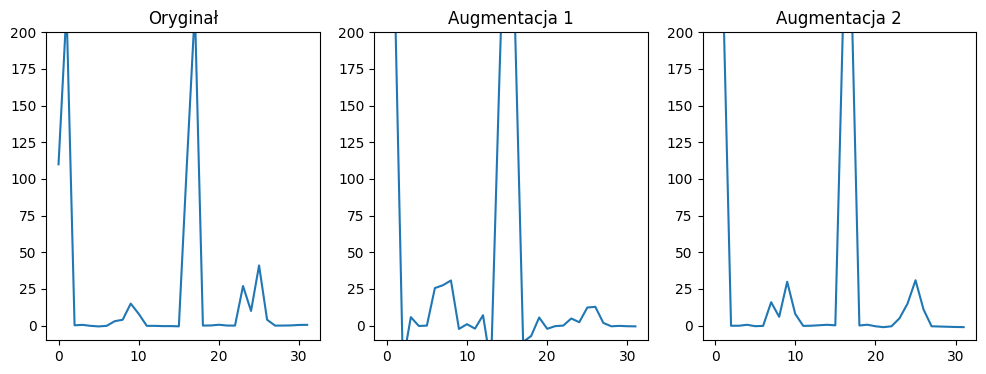

In [5]:
import matplotlib.pyplot as plt

X_test_aug, y_test_aug = augment_minority_classes(X_train_preproc[:100], y_train[:100])

plt.figure(figsize=(12, 4))

# Oryginał
plt.subplot(1, 3, 1)
plt.plot(X_train_preproc[0])
plt.title("Oryginał")
plt.ylim(-10, 200)

# Augmentacja 1
plt.subplot(1, 3, 2)
plt.plot(X_test_aug[105])
plt.title("Augmentacja 1")
plt.ylim(-10, 200)

# Augmentacja 2
plt.subplot(1, 3, 3)
plt.plot(X_test_aug[110])
plt.title("Augmentacja 2")
plt.ylim(-10, 200)

plt.show()

### Model najbliższy do baseline

In [9]:

# AKTUALNIE CHYBA NAJLEPSZA SIEĆ - CONSISTENTLY OK 80%
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),  
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8379 - loss: 0.2621 - val_f1_score: 0.7314 - val_loss: 0.0679
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8379 - loss: 0.2621 - val_f1_score: 0.7314 - val_loss: 0.0679
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9056 - loss: 0.1615 - val_f1_score: 0.7689 - val_loss: 0.0544
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9056 - loss: 0.1615 - val_f1_score: 0.7689 - val_loss: 0.0544
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9209 - loss: 0.1396 - val_f1_score: 0.7617 - val_loss: 0.0539
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9209 - loss: 0.1396 - val_f1_score: 0.7617 - val_loss: 0.0539
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9251 - loss: 0.1306 - val_f1_score: 0.7776 - val_loss: 0.0457
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.9251 - loss: 0

In [28]:

# TA SAMA ARCHITEKTURA CO POWYŻEJ ALE Z INNĄ FUNKCJĄ STRATY
deep_rnn = models.Sequential([
    layers.Input(shape=(X_train_preproc.shape[1], X_train_preproc.shape[2])),
    
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),
    
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', kernel_regularizer=regularizers.L2(0.0005)),
    layers.BatchNormalization(),  
    layers.MaxPooling1D(pool_size=2),
    # layers.Dropout(0.2),

    layers.Flatten(),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

deep_rnn.compile(loss="categorical_focal_crossentropy",
                 optimizer=optimizers.Adam(learning_rate=0.001),
                 metrics=[metrics.F1Score(average="macro")])

log_dir = "../logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1, update_freq="batch")
# early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_f1_score", restore_best_weights=True)


history = deep_rnn.fit(train_ds,
                       validation_data=val_ds,
                       epochs=30,
                       callbacks=[
                           tensorboard_callback, 
                        #    early_stopping
                        ],
                       )

deep_rnn.save("models/1d_cnn.keras")

Epoch 1/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8222 - loss: 0.0348 - val_f1_score: 0.7442 - val_loss: 0.0089
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - f1_score: 0.8222 - loss: 0.0348 - val_f1_score: 0.7442 - val_loss: 0.0089
Epoch 2/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.8896 - loss: 0.0196 - val_f1_score: 0.7456 - val_loss: 0.0084
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - f1_score: 0.8896 - loss: 0.0196 - val_f1_score: 0.7456 - val_loss: 0.0084
Epoch 3/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - f1_score: 0.9075 - loss: 0.0162 - val_f1_score: 0.7587 - val_loss: 0.0075
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - f1_score: 0.9075 - loss: 0.0162 - val_f1_score: 0.7587 - val_loss: 0.0075
Epoch 4/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - f1_score: 0.9143 - loss: 0.0149 - val_f1_score: 0.7401 - val_loss: 0.0073
Epoch 5/30
5339/5339 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - f1_score: 0.9143 - loss: 0

## WYNIKI DLA SIECI

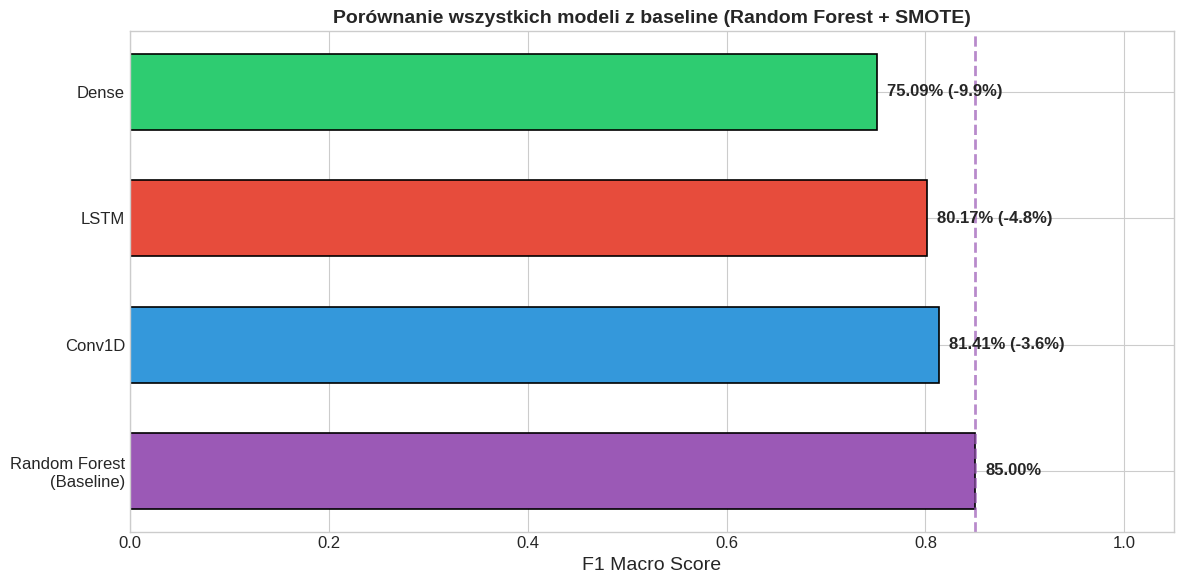


PODSUMOWANIE WYNIKÓW
Model                     F1 Macro     vs Baseline 
------------------------------------------------------------
Random Forest (Baseline)  85.00%       -           
Conv1D                    81.41%       -3.59%      
LSTM                      80.17%       -4.83%      
Dense                     75.09%       -9.91%      


In [ ]:
# Zestawienie porównawcze - wykres poziomy z różnicą do baseline
fig, ax = plt.subplots(figsize=(12, 6))

models_compare = ['Random Forest\n(Baseline)', 'Conv1D', 'LSTM', 'Dense']
scores_compare = [0.85, 0.8141, 0.8017, 0.7509]
colors_compare = ['#9b59b6', '#3498db', '#e74c3c', '#2ecc71']

# Sortowanie według wyniku
sorted_data = sorted(zip(models_compare, scores_compare, colors_compare), key=lambda x: x[1], reverse=True)
models_sorted, scores_sorted, colors_sorted = zip(*sorted_data)

bars = ax.barh(models_sorted, scores_sorted, color=colors_sorted, edgecolor='black', linewidth=1.2, height=0.6)

# Dodanie wartości i różnicy do baseline
baseline = 0.85
for bar, score, model in zip(bars, scores_sorted, models_sorted):
    width = bar.get_width()
    diff = score - baseline
    diff_str = f" ({diff:+.1%})" if model != 'Random Forest\n(Baseline)' else ""
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2%}{diff_str}',
            va='center', ha='left', fontsize=12, fontweight='bold')

# Linia baseline
ax.axvline(x=0.85, color='#9b59b6', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('F1 Macro Score', fontsize=14)
ax.set_title('Porównanie wszystkich modeli z baseline (Random Forest + SMOTE)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('../figures/model_comparison_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Podsumowanie liczbowe
print("\n" + "="*60)
print("PODSUMOWANIE WYNIKÓW")
print("="*60)
print(f"{'Model':<25} {'F1 Macro':<12} {'vs Baseline':<12}")
print("-"*60)
for model, score in zip(models_sorted, scores_sorted):
    diff = score - baseline
    diff_str = f"{diff:+.2%}" if model != 'Random Forest\n(Baseline)' else "-"
    print(f"{model.replace(chr(10), ' '):<25} {score:<12.2%} {diff_str:<12}")
print("="*60)